In [16]:
import os
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics
import subprocess
import sys
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix
import scanpy.external as sce
from sklearn.metrics import silhouette_score
import datetime
import numpy as np
from collections import defaultdict
import scipy.sparse as sp
from collections import defaultdict
import gffutils 
import scipy.sparse as sp
import gffutils 
from scipy.stats import spearmanr, pearsonr
from scipy import stats

from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.optimize import minimize

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from collections import defaultdict
import pandas as pd
import os
import gffutils
from tqdm import tqdm
from intervaltree import IntervalTree

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation


In [17]:
# %%
def extract_gene_transcript_info(gtf_file, db_file):
    """
    Parses a GENCODE GTF file to compute:
    - Mean transcript length per gene (sum of exons)
    - Mean intron length per gene (transcript span - exon length)
    - Number of transcripts per gene
    - Transcript biotypes
    - Gene name
    
    Returns a DataFrame with gene_id, gene_name, mean_transcript_length, mean_intron_length, 
    num_transcripts, and transcript_biotypes.
    """

    if os.path.exists(db_file):
        print("Using existing GTF database.")
        db = gffutils.FeatureDB(db_file, keep_order=True)
        print("Database loaded successfully!")
    else:
        print("Creating GTF database (this may take a few minutes)...")
        db = gffutils.create_db(
            gtf_file,
            db_file,
            force=True,
            keep_order=True,
            disable_infer_transcripts=False,
            disable_infer_genes=True
        )
        print("Database created successfully!")

    gene_exon_lengths = defaultdict(list)
    gene_intron_lengths = defaultdict(list)
    gene_names = {}
    gene_biotypes = defaultdict(set)
    transcript_counts = defaultdict(int)

    print("Processing transcripts to compute exon and intron lengths...")
    for transcript in tqdm(db.features_of_type("transcript"), desc="Processing Transcripts", unit=" transcript"):
        gene_id = transcript.attributes["gene_id"][0]
        gene_name = transcript.attributes.get("gene_name", ["unknown"])[0]
        transcript_biotype = transcript.attributes.get("transcript_type", ["unknown"])[0]

        exons = list(db.children(transcript, featuretype="exon", order_by="start"))
        if len(exons) == 0:
            continue  # skip transcripts with no exons

        exon_length = sum(exon.end - exon.start + 1 for exon in exons)
        transcript_start = exons[0].start
        transcript_end = exons[-1].end
        transcript_span = transcript_end - transcript_start + 1
        intron_length = transcript_span - exon_length  # includes gaps between exons

        gene_exon_lengths[gene_id].append(exon_length)
        gene_intron_lengths[gene_id].append(max(0, intron_length))  # avoid negative values
        gene_names[gene_id] = gene_name
        gene_biotypes[gene_id].add(transcript_biotype)
        transcript_counts[gene_id] += 1

    print("Finished processing transcripts.")

    gene_ids = list(gene_exon_lengths.keys())
    gene_info_df = pd.DataFrame({
        "gene_id": gene_ids,
        "gene_name": [gene_names[g] for g in gene_ids],
        "mean_transcript_length": [sum(gene_exon_lengths[g]) / len(gene_exon_lengths[g]) for g in gene_ids],
        "mean_intron_length": [sum(gene_intron_lengths[g]) / len(gene_intron_lengths[g]) for g in gene_ids],
        "num_transcripts": [transcript_counts[g] for g in gene_ids],
        "transcript_biotypes": [", ".join(sorted(gene_biotypes[g])) for g in gene_ids]
    })

    return gene_info_df

gtf_hg38 = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode.v45.primary_assembly.annotation.gtf"
db_file = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode_hg38.db"

# Get lengths of genes 
gene_info_df = extract_gene_transcript_info(gtf_hg38, db_file)
gene_info_df = gene_info_df.drop_duplicates(subset="gene_id")
gene_info_df = gene_info_df.drop_duplicates(subset="gene_name")

Using existing GTF database.
Database loaded successfully!
Processing transcripts to compute exon and intron lengths...


Processing Transcripts: 252989 transcript [01:53, 2231.64 transcript/s]


Finished processing transcripts.


In [48]:
# Open the files 
WD="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/processed_data"

controls=f"{WD}/pseudobulk_microglia_macrophage_controls.tsv"
controls = pd.read_csv(controls, sep="\t")
controls["gene_name"] = controls["gene"]
controls = controls.merge(gene_info_df, on="gene_name", how="left")
controls = controls[(controls["mean_transcript_length"] > 0) & (controls["mean_intron_length"] > 0)]
print(f"Number of genes remaining: {len(controls)}")

# First Divide BY lengths 
controls["norm_ex"] = controls["ab_exons_ctrl_sum"]/controls["mean_transcript_length"]
controls["norm_int"] = controls["ab_introns_ctrl_sum"]/controls["mean_intron_length"]
controls["norm_ts"] = controls["ts_ctrl_sum"]/controls["mean_transcript_length"]

controls["cell_type"] = "Controls"

controls["log_norm_ex"] = np.log1p(controls["norm_ex"])
controls["log_norm_int"] = np.log1p(controls["norm_int"])
controls["log_norm_ts"] = np.log1p(controls["norm_ts"])

controls = controls[~controls["transcript_biotypes"].str.contains("lncRNA")]
# remove any retained_intron genes
controls = controls[~controls["transcript_biotypes"].str.contains("retained_intron")]

Number of genes remaining: 21200


In [49]:
common_broad_types = ['Stromal', 'Pericyte', 'Glia', 'Microglia_Macrophage']
common_broad_types = ['Microglia_Macrophage']

# Make an empty list to store the dataframes
df_list = []

for cell in common_broad_types:
    print(f"Reading and processing pseudobulk counts for {cell}...")
    cell_type = pd.read_csv(f"{WD}/pseudobulk_{cell}.tsv", sep="\t")
    cell_type["gene_name"] = cell_type["gene"]
    cell_type = cell_type.merge(gene_info_df, on="gene_name", how="left")
    cell_type = cell_type[(cell_type["mean_transcript_length"] > 0) & (cell_type["mean_intron_length"] > 0)]

    # First divide by either exon or intron lengths 
    cell_type["norm_ex"] = cell_type["ab_exons_sum"]/cell_type["mean_transcript_length"]
    cell_type["norm_int"] = cell_type["ab_introns_sum"]/cell_type["mean_intron_length"]
    cell_type["norm_ts"] = cell_type["ts_sum"]/cell_type["mean_transcript_length"]

    cell_type["cell_type"] = cell
    df_list.append(cell_type)

# Combine df_list into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

# Normalize length normalized values by library size (sum of all genes)
combined_df["norm_ex"] = combined_df["norm_ex"] / combined_df["norm_ex"].sum() * 10000
combined_df["norm_int"] = combined_df["norm_int"] / combined_df["norm_int"].sum() * 10000
combined_df["norm_ts"] = combined_df["norm_ts"] / combined_df["norm_ts"].sum() * 10000

# Apply log1p to the length normalized values 
combined_df["log_norm_ex"] = np.log1p(combined_df["norm_ex"])
combined_df["log_norm_int"] = np.log1p(combined_df["norm_int"])
combined_df["log_norm_ts"] = np.log1p(combined_df["norm_ts"])

# remove any lncRNA genes or retained intron genes 
# combined_df = combined_df[~combined_df["transcript_biotypes"].str.contains("lncRNA")]
# combined_df = combined_df[~combined_df["transcript_biotypes"].str.contains("retained_intron")]
print(f"Number of genes remaining: {len(combined_df)}")

# Save compressed dataframe
combined_df.to_csv(f"{WD}/pseudobulk_combined.tsv", sep="\t", index=False, compression="gzip")

Reading and processing pseudobulk counts for Microglia_Macrophage...
Number of genes remaining: 21200


### Train two models 
1. Linear regression using norm_ex + norm int as predictors of ts_s (raw counts normalized by average transcript length) y ~ B0e + B1i
2. Non linear version with log "activation" function --> log y ~ log(B0e + B1i + c)

For each model, we want to look at residuals between y_prep and y, R^2 values, coefficients for exon and intron Betas and correlation between y and y_pred --> which models gives us the best performance here 
Summarize all this info in a table... 

In [50]:
combined_df.cell_type.value_counts()

cell_type
Microglia_Macrophage    21200
Name: count, dtype: int64

<Axes: >

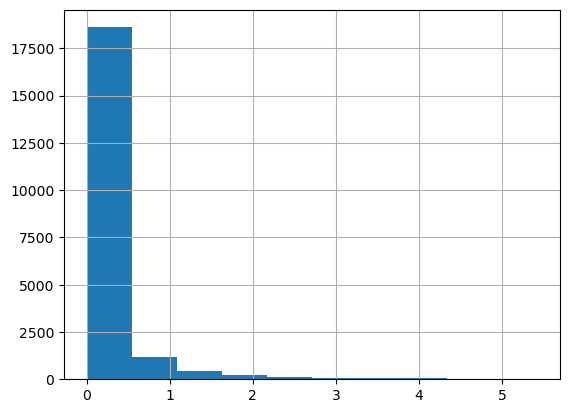

In [51]:
# remove combined_df values with norm_ex or norm_ts  that are outliers 
outlier_val = combined_df["norm_ex"].quantile(0.99)
combined_df = combined_df[combined_df["norm_ex"] < outlier_val]
outlier_val = combined_df["norm_ts"].quantile(0.99)
combined_df = combined_df[combined_df["norm_ts"] < outlier_val]

combined_df["norm_ts"].hist()

In [52]:
combined_df

,gene,ab_exons_sum,ab_introns_sum,ts_sum,gene_name,gene_id,mean_transcript_length,mean_intron_length,num_transcripts,transcript_biotypes,norm_ex,norm_int,norm_ts,cell_type,log_norm_ex,log_norm_int,log_norm_ts
0,A1BG,2107.0,84.0,916,A1BG,ENSG00000121410.12,1841.800000,2305.200000,5,"protein_coding, protein_coding_CDS_not_defined...",0.063851,0.023019,0.002603,Microglia_Macrophage,0.061896,0.022758,0.002600
1,A1BG-AS1,26.0,85.0,2481,A1BG-AS1,ENSG00000268895.6,1453.555556,4747.666667,9,lncRNA,0.000998,0.011310,0.008935,Microglia_Macrophage,0.000998,0.011246,0.008895
2,A1CF,9.0,77.0,768,A1CF,ENSG00000148584.16,3446.333333,65576.777778,9,"protein_coding, protein_coding_CDS_not_defined",0.000146,0.000742,0.001167,Microglia_Macrophage,0.000146,0.000741,0.001166
4,A2M-AS1,1510.0,122.0,6314,A2M-AS1,ENSG00000245105.4,2357.500000,988.250000,4,lncRNA,0.035750,0.077985,0.014020,Microglia_Macrophage,0.035126,0.075094,0.013922
5,A2ML1,96.0,3872.0,565,A2ML1,ENSG00000166535.20,1749.000000,15763.888889,9,"nonsense_mediated_decay, protein_coding, prote...",0.003064,0.155164,0.001691,Microglia_Macrophage,0.003059,0.144243,0.001690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21195,ZYG11AP1,1.0,0.0,2,ZYG11AP1,ENSG00000232242.2,837.000000,157.000000,1,processed_pseudogene,0.000067,0.000000,0.000013,Microglia_Macrophage,0.000067,0.000000,0.000013
21196,ZYG11B,22834.0,28880.0,72051,ZYG11B,ENSG00000162378.13,5218.500000,90309.500000,2,protein_coding,0.244221,0.202015,0.072275,Microglia_Macrophage,0.218510,0.184000,0.069782
21197,ZYX,5412.0,321.0,823605,ZYX,ENSG00000159840.16,1140.500000,3539.300000,10,"nonsense_mediated_decay, protein_coding, prote...",0.264856,0.057294,3.780199,Microglia_Macrophage,0.234958,0.055713,1.564482
21198,ZZEF1,11817.0,46427.0,154945,ZZEF1,ENSG00000074755.15,2785.545455,30053.272727,11,"nonsense_mediated_decay, protein_coding, prote...",0.236780,0.975886,0.291178,Microglia_Macrophage,0.212511,0.681017,0.255555


Linear Model Summary:
                            OLS Regression Results                            
Dep. Variable:                norm_ts   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.290
Method:                 Least Squares   F-statistic:                     4238.
Date:                Wed, 23 Apr 2025   Prob (F-statistic):               0.00
Time:                        18:28:00   Log-Likelihood:                -12073.
No. Observations:               20778   AIC:                         2.415e+04
Df Residuals:                   20775   BIC:                         2.418e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0653      0.0

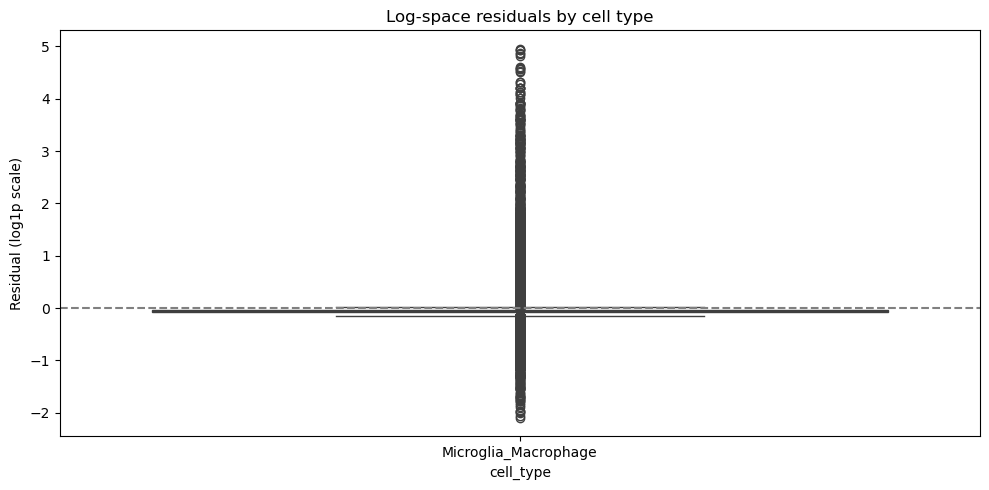

Saved model to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/linear_norm_ts_model.pkl


In [53]:
# ---------------------------------------------------
# 1. Linear regression: y ~ B0e + B1i 
# ---------------------------------------------------

# Prepare the data
X_linear = pd.DataFrame({
    'exons': combined_df['norm_ex'],
    'introns': combined_df['norm_int']
})

# Prep cell type as categorical variable for X 
# X_linear = pd.get_dummies(X_linear, columns=['cell_type'], drop_first=True)
# if 'cell_type' in X_linear.columns:
#     X_linear = X_linear.drop(columns=['cell_type'])
X_linear = sm.add_constant(X_linear)  # Add intercept
y_linear = combined_df['norm_ts']

# Ensure both X and y are float dtype
X_linear = X_linear.astype(float)
y_linear = y_linear.astype(float)

# Fit the model
model_linear = sm.OLS(y_linear, X_linear).fit()
y_pred_linear = model_linear.predict(X_linear)

# Clip the predictions to avoid negative values? 
# y_pred_linear = np.clip(y_pred_linear, 0, None)

# Calculate metrics
r2_linear = model_linear.rsquared
rmse_linear = np.sqrt(np.mean((y_linear - y_pred_linear) ** 2))
combined_df["log_residual"] = y_linear - y_pred_linear
combined_df["linear_pred"] = y_pred_linear
print("Linear Model Summary:")
print(model_linear.summary())

plt.figure(figsize=(10, 5))
sns.boxplot(data=combined_df, x="cell_type", y="log_residual")
plt.axhline(0, linestyle='--', color='gray')
plt.ylabel("Residual (log1p scale)")
plt.title("Log-space residuals by cell type")
plt.tight_layout()
plt.show()

import pickle
output_dir=current_dir

# Save the model to a file
with open(f"{output_dir}/linear_norm_ts_model.pkl", "wb") as f:
    pickle.dump(model_linear, f)

# can use model_loaded.predict(X_linear) or model_loaded.summary()
print(f"Saved model to {output_dir}/linear_norm_ts_model.pkl")

Spearman correlation for Microglia_Macrophage: 0.79 (p-value: 0.00e+00)
Pearson correlation for Microglia_Macrophage: 0.54 (p-value: 0.00e+00)


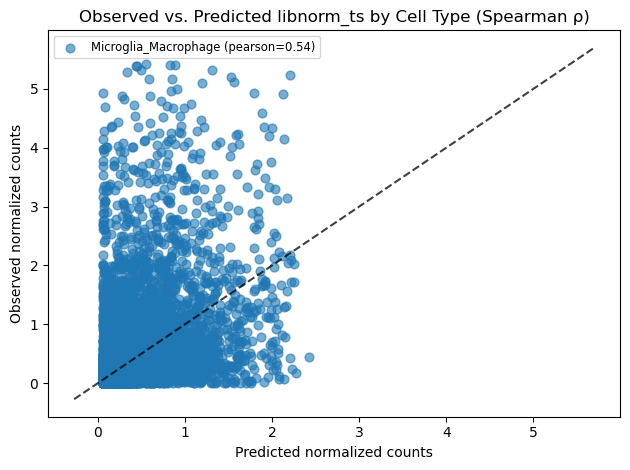

In [ ]:
# Unique cell types
cell_types = combined_df['cell_type'].unique()
colors = sns.color_palette("tab10", len(cell_types))

# Loop through each cell type
for i, cell in enumerate(cell_types):
    sub = combined_df[combined_df['cell_type'] == cell]

    # Calculate Spearman correlation
    rho, pval = spearmanr(sub['linear_pred'], sub['norm_ts'])
    # Calculate Pearson correlation
    pearson_corr, pval_pearson = pearsonr(sub['linear_pred'], sub['norm_ts'])
    print(f"Spearman correlation for {cell}: {rho:.2f} (p-value: {pval:.2e})")
    print(f"Pearson correlation for {cell}: {pearson_corr:.2f} (p-value: {pval_pearson:.2e})")

    # Plot points
    plt.scatter(sub['linear_pred'], sub['norm_ts'], label=f"{cell} (pearson={pearson_corr:.2f})", alpha=0.6, s=40, color=colors[i])

# Add reference line (optional)
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'k--', alpha=0.75)

# Labels and legend
plt.xlabel("Predicted normalized counts")
plt.ylabel("Observed normalized counts")
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()


Spearman correlation for Microglia_Macrophage: 0.79 (p-value: 0.00e+00)
Pearson correlation for Microglia_Macrophage: 0.54 (p-value: 0.00e+00)


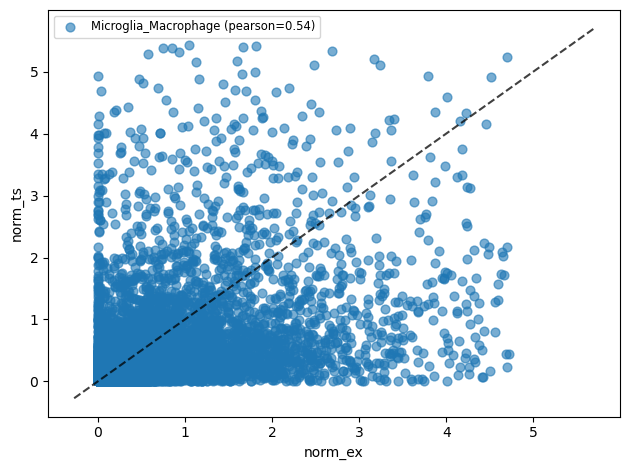

In [55]:
# Loop through each cell type
for i, cell in enumerate(cell_types):
    sub = combined_df[combined_df['cell_type'] == cell]

    # Calculate Spearman correlation
    rho, pval = spearmanr(sub['norm_ex'], sub['log_norm_ts'])
    # Calculate Pearson correlation
    pearson_rho, pearson_pval = pearsonr(sub['norm_ex'], sub['norm_ts'])
    print(f"Spearman correlation for {cell}: {rho:.2f} (p-value: {pval:.2e})")
    print(f"Pearson correlation for {cell}: {pearson_rho:.2f} (p-value: {pearson_pval:.2e})")
    # Plot points
    plt.scatter(sub['norm_ex'], sub['norm_ts'], label=f"{cell} (pearson={pearson_rho:.2f})", alpha=0.6, s=40, color=colors[i])

# Add reference line (optional)
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'k--', alpha=0.75)

# Labels and legend
plt.xlabel("norm_ex")
plt.ylabel("norm_ts")
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()


In [ ]:
# plot expression of CXCL8 by cell type 
gene_names = np.random.choice(combined_df["gene_name"], size=100)
gene_data = combined_df[combined_df["gene_name"].isin(gene_names)]
print(gene_data)
# plot observed log exp vs predicted log exp
plt.figure(figsize=(5, 5))
sns.scatterplot(data=gene_data, x="linear_pred", y="log_norm_ts", hue="cell_type",s=50)
plt.xlabel("linear_pred")
plt.ylabel("Observed log_norm_ts")
# xlim and ylim make the same based on max value 
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'k--', alpha=0.75)


### not always a nice positive relationship like what we would expect

In [ ]:
# ---------------------------------------------------
# 2. Non-linear model: log y ~ log(B0e + B1i + c)
# ---------------------------------------------------

# Non-linear model: log y ~ log(B0*e + B1*i + c) + d
def model(params, e, i):
    B0, B1, c, d = params
    pred = np.log((B0 * e) + (B1 * i) + c) + d
    return pred

# Loss function in log-space (no need to log y again)
def loss(params, e, i, y_log):
    pred = model(params, e, i)
    return np.sum((y_log - pred)**2)

# Use your combined_df with current variable names
e = combined_df["log_norm_ex"].values
i = combined_df["log_norm_int"].values
y_log = combined_df["log_norm_ts"].values

# Initial guess and optimization
init_params = [1.0, 1.0, 1.0, 0.0]
res = minimize(loss, init_params, args=(e, i, y_log), method='L-BFGS-B', bounds=[(None, None), (None, None), (1e-9, None), (None, None)])

# Extract optimal parameters
B0_opt, B1_opt, c_opt, d_opt = res.x
print(f"Optimized B0 = {B0_opt:.4f}, B1 = {B1_opt:.4f}, c = {c_opt:.4f}, d = {d_opt:.4f}")

# Predict
y_pred = model(res.x, e, i)
residuals = y_log - y_pred

# Metrics
ss_res = np.sum((y_log - y_pred) ** 2)
ss_tot = np.sum((y_log - np.mean(y_log)) ** 2)
r2_nonlinear = 1 - ss_res / ss_tot
rmse_nonlinear = np.sqrt(np.mean((y_log - y_pred) ** 2))
corr_nonlinear = np.corrcoef(y_log, y_pred)[0, 1]

print(f"R² (nonlinear): {r2_nonlinear:.4f}")
print(f"RMSE (nonlinear): {rmse_nonlinear:.4f}")
print(f"Correlation (log-space): {corr_nonlinear:.4f}")

# Add residuals back to DataFrame
combined_df["logmodel_residual"] = residuals

# Optional: check residuals by cell type
combined_df.groupby("cell_type")["logmodel_residual"].describe()

In [ ]:
# add pearson and spearman correlation 

In [ ]:
sns.boxplot(data=combined_df, x="cell_type", y="logmodel_residual")